# 📘 Suite du TP – Analyse des performances d’étudiants

🎯 **Objectif :** Approfondir la préparation du dataset pour une régression linéaire multiple en appliquant la standardisation, la réduction de dimension et la suppression des variables corrélées.

## 🔄 7. Normalisation et standardisation

**0** Comprendre la notion de normalisation et de standardisation 

**21.** Standardisez toutes les colonnes numériques de `X` (moyenne 0, écart-type 1) à l’aide de `StandardScaler`.

**22.** Comparez les résultats avec une normalisation min-max (`MinMaxScaler`).

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

import pandas as pd

X = pd.read_csv("X.csv")
y = pd.read_csv("y.csv")

scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

In [2]:
X_scaled.describe()

,gender,parent_edu_associate's degree,parent_edu_bachelor's degree,parent_edu_high school,parent_edu_master's degree,parent_edu_some college,parent_edu_some high school,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,lunch_free/reduced,lunch_standard,test preparation course_completed,test preparation course_none
count,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1000.000000,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03
mean,4.263256e-17,-2.842171e-17,7.727152e-17,-7.105427e-18,-2.131628e-17,3.552714e-18,-6.217249e-17,-4.440892e-18,0.000000,6.927792e-17,-3.552714e-17,-2.842171e-17,1.953993e-17,-1.953993e-17,-3.375078e-17,3.375078e-17
std,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00
min,-9.646253e-01,-5.341788e-01,-3.657688e-01,-4.937419e-01,-2.503982e-01,-5.403607e-01,-4.669334e-01,-3.125617e-01,-0.484322,-6.844186e-01,-5.958301e-01,-4.034733e-01,-7.418811e-01,-1.347925e+00,-7.467479e-01,-1.339140e+00
25%,-9.646253e-01,-5.341788e-01,-3.657688e-01,-4.937419e-01,-2.503982e-01,-5.403607e-01,-4.669334e-01,-3.125617e-01,-0.484322,-6.844186e-01,-5.958301e-01,-4.034733e-01,-7.418811e-01,-1.347925e+00,-7.467479e-01,-1.339140e+00
50%,-9.646253e-01,-5.341788e-01,-3.657688e-01,-4.937419e-01,-2.503982e-01,-5.403607e-01,-4.669334e-01,-3.125617e-01,-0.484322,-6.844186e-01,-5.958301e-01,-4.034733e-01,-7.418811e-01,7.418811e-01,-7.467479e-01,7.467479e-01
75%,1.036672e+00,-5.341788e-01,-3.657688e-01,-4.937419e-01,-2.503982e-01,-5.403607e-01,-4.669334e-01,-3.125617e-01,-0.484322,1.461094e+00,1.678331e+00,-4.034733e-01,1.347925e+00,7.418811e-01,1.339140e+00,7.467479e-01
max,1.036672e+00,1.872032e+00,2.733967e+00,2.025350e+00,3.993639e+00,1.850616e+00,2.141633e+00,3.199368e+00,2.064742,1.461094e+00,1.678331e+00,2.478479e+00,1.347925e+00,7.418811e-01,1.339140e+00,7.467479e-01


## 🔁 8. Suppression des variables trop corrélées

**0.** Comprendre la notion de corrélation linéaire. 

**23.** Calculez la **matrice de corrélation** entre les variables explicatives (`X`).

**24.** Supprimez les variables dont la corrélation dépasse un seuil (ex : > 0.9).

**25.** Réaffichez la heatmap pour valider.

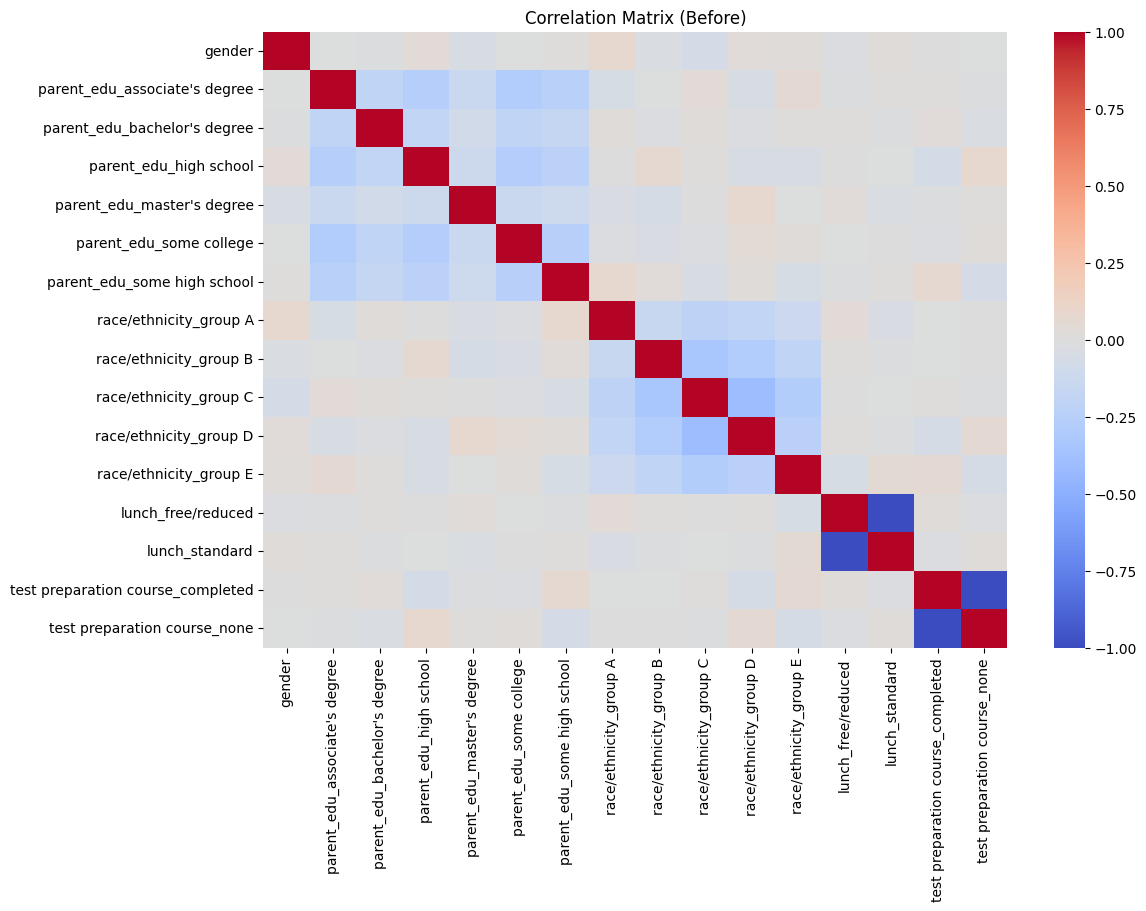

Variables supprimées : ['lunch_standard', 'test preparation course_none']


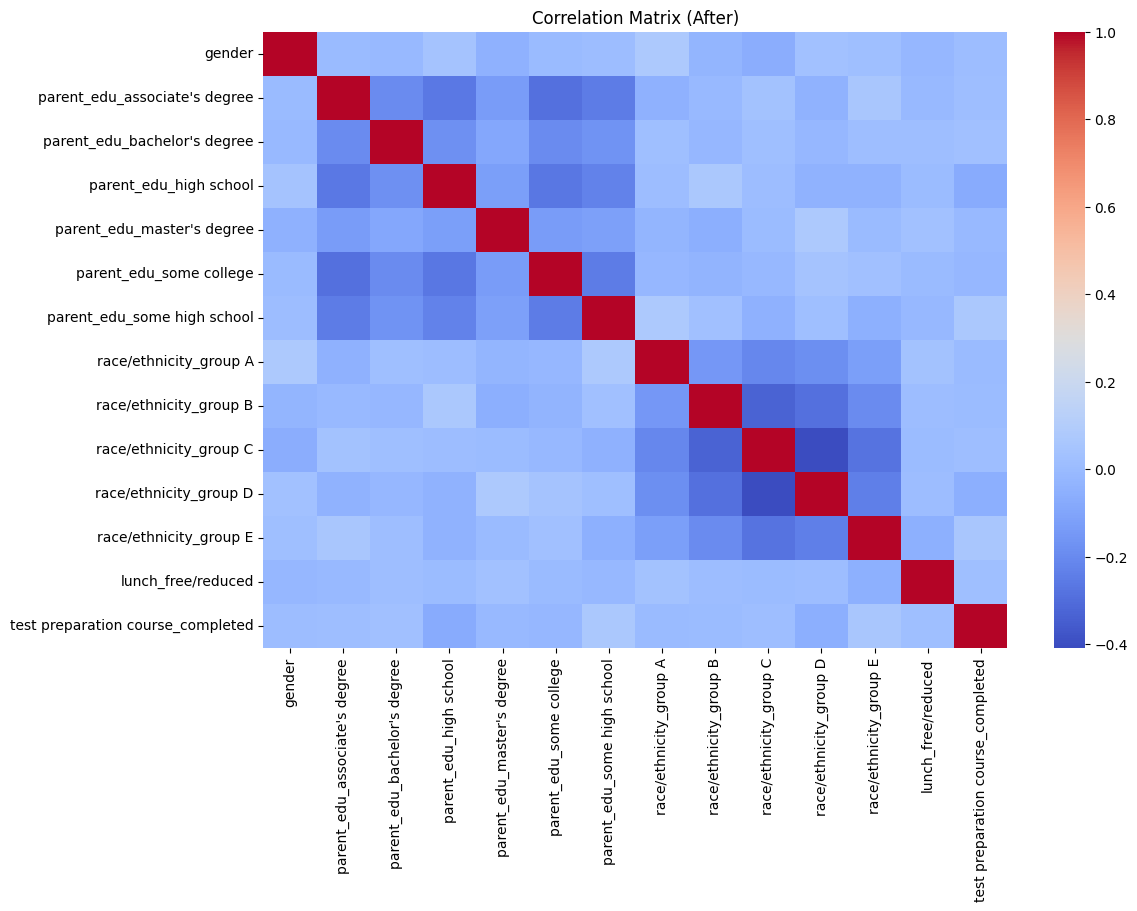

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Matrice de corrélation
corr_matrix = X.corr()

# 2. Heatmap initiale
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap="coolwarm")
plt.title("Correlation Matrix (Before)")
plt.show()

# 3. Détection des variables fortement corrélées (> 0.9)
corr_abs = corr_matrix.abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]

print("Variables supprimées :", to_drop)

# 4. Suppression
X_reduced = X.drop(columns=to_drop)

# 5. Nouvelle matrice de corrélation
corr_matrix_reduced = X_reduced.corr()

# 6. Heatmap après suppression
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix_reduced, cmap="coolwarm")
plt.title("Correlation Matrix (After)")
plt.show()

## 🧬 9. Réduction de dimension (PCA)

**0.** Comprendre la notion de réduction de dimension. Essayer de comprendre PCA globalement

**26.** Appliquez une **PCA** sur les données standardisées.

**27.** Affichez la variance expliquée par chaque composante.

**28.** Tracez un nuage de points 2D selon les 2 premières composantes.

Variance expliquée par composante :
[1.28541550e-01 1.25157575e-01 9.17854620e-02 8.64625528e-02
 8.11137952e-02 7.84319958e-02 7.55745189e-02 7.39318152e-02
 7.12718398e-02 6.72275370e-02 6.26605271e-02 5.78408315e-02
 1.94237527e-17 1.15440241e-33 0.00000000e+00 0.00000000e+00]

Variance cumulée :
[0.12854155 0.25369912 0.34548459 0.43194714 0.51306093 0.59149293
 0.66706745 0.74099926 0.8122711  0.87949864 0.94215917 1.
 1.         1.         1.         1.        ]


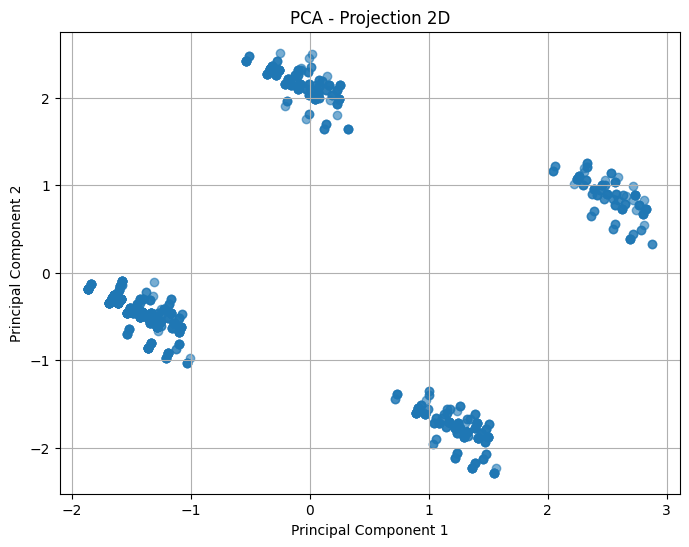

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 3. Variance expliquée
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("Variance expliquée par composante :")
print(explained_variance)

print("\nVariance cumulée :")
print(cumulative_variance)

# 4. Graphique 2D (PC1 vs PC2)
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - Projection 2D")
plt.grid(True)

plt.show()